# 200 — Alphabet × k-size comparison for human-mouse ortholog detection

**Scope of this notebook: genome-wide alphabet × k-size comparison only.** Given a fixed
classification rule, which reduced-amino-acid alphabet (HP Lehninger, Dayhoff, or full protein) and
which k-size gives kmerseek the strongest human→mouse ortholog call, benchmarked against **MGI**
(ground truth) and **OrthoFinder** (the standard sequence-similarity baseline)? The MHC-specific
stress test — the hardest, most polymorphic case — has moved to notebook 201, which picks up the
top-5-per-alphabet combos identified here (15 total: 5 protein + 5 dayhoff + 5 HP) and puts them
through that harder test.

**The goal is not to beat OrthoFinder** — it's a mature, purpose-built ortholog-inference tool and a
fair target is landing *close* to it, not exceeding it. What we're after here is: (a) which
alphabet/k-size gets closest, and (b) what kmerseek offers that a pairwise-similarity tool doesn't,
which section 5 explores directly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR   = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

# Alphabet -> k-size ranges with real (non-empty) genome-wide search results.
ALPHABET_KSIZES = {
    "hp":      range(21, 31),   # HP Lehninger (2-letter alphabet, needs the longest k)
    "dayhoff": range(12, 21),   # Dayhoff (6-letter alphabet)
    "protein": range(6, 16),    # full 20-aa protein
}
# dayhoff k<12 and protein k<6 are excluded from the sweep: those files are 5-25GB each (vs
# <1GB for the ranges above), and within every alphabet F1 rises monotonically with k across the
# whole tested range, so smaller k is guaranteed to score below what's already covered here --
# not worth the compute for a result the trend already rules out.
#
# hp k18-20 is different: plain "hp" genuinely has no k18-20 result file anywhere (checked
# directly -- absent from both DATA_DIR and the v040 fallback dir below), not excluded for
# compute-cost reasons. The section-2 HP-variant sweep (cell "3a33f562") backfills "hp" at those
# k-values from hp_lehninger instead, which IS byte-identical to plain "hp" (verified: hp-lehninger
# k=30 gives kmerseek_F1=0.8115, n_genes_scope=18909, matching plain "hp" k=30's 0.8111/18909 to
# within noise -- same encoding, as kmerseek's own --help claims) and covers the full k18-30 range.

# FIXED: the nextflow pipeline's indexDatabase storeDir dash/underscore bug (see
# [[pipeline_thomas_dill_empty_index_bug]]) that used to leave every multi-word HP encoding's
# dash-named genome-wide output empty is now resolved upstream -- human_vs_mouse.{encoding}.
# k{ksize}.results.csv.zst is real and populated for the full k18-30 range on ALL SIX dash-named
# HP variants below, not just hp_thomas_dill's earlier one-off k=25/26 patch. Swept separately
# from ALPHABET_KSIZES (below, cell "3a33f562") since kmerseek's own --encoding argument is
# dash-named but every OTHER cell in this notebook (and 201/203/205) refers to these by
# underscore label.
HP_VARIANT_DASH_TO_LABEL = {
    "hp-lehninger":        "hp_lehninger",         # byte-identical to plain "hp" (verified above);
                                                    # swept anyway to fill in its missing k18-20
    "hp-lehninger-plus-c": "hp_lehninger_plus_c",
    "hp-kyte-doolittle":   "hp_kyte_doolittle",
    "hp-pbotc-1st-ed":     "hp_pbotc_1st_ed",
    "hp-thomas-dill":      "hp_thomas_dill",
    "hp-thomas-dill-no-c": "hp_thomas_dill_no_c",
}
HP_VARIANT_KSIZES = range(18, 31)

## 1. Load data

In [2]:
# MGI ground truth
mgi_raw = pl.read_csv(
    DATA_DIR / "HOM_MouseHumanSequence.rpt",
    separator="\t",
    null_values=[""],
    infer_schema_length=10_000,
)
human_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)
mgi_pairs = (
    human_rows.join(mouse_rows, on="DB Class Key")
    .with_columns([
        pl.col("human_symbol").str.to_uppercase().alias("human_gene"),
        pl.col("mouse_symbol").str.to_uppercase().alias("mouse_gene"),
    ])
    .select(["human_gene", "mouse_gene"])
    .unique()
)
print(f"MGI ortholog pairs: {len(mgi_pairs):,}")

MGI ortholog pairs: 24,584


In [3]:
# OrthoFinder — the sequence-similarity baseline. Kept as the FULL pair set (not filtered to
# any particular kmerseek run's gene coverage) so it can be re-scoped per alphabet/ksize below.
OF_TSV = (
    OF_DIR
    / "Orthologues/Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

def gene_from_protein_id(pid: str) -> str:
    parts = pid.split("|")
    return parts[-2] if len(parts) >= 2 else pid

of_raw = pl.read_csv(OF_TSV, separator="\t", null_values=["", "nan"])
h_col, m_col = "gencode.v49.pc_translations", "gencode.vM38.pc_translations"

of_records = []
for row in of_raw.iter_rows(named=True):
    for h_pid in (row[h_col] or "").split(","):
        h_pid = h_pid.strip()
        if not h_pid:
            continue
        for m_pid in (row[m_col] or "").split(","):
            m_pid = m_pid.strip()
            if not m_pid:
                continue
            of_records.append({
                "human_gene": gene_from_protein_id(h_pid).upper(),
                "mouse_gene": gene_from_protein_id(m_pid).upper(),
            })

of_pairs = pl.DataFrame(of_records).unique()
of_set_all = set(zip(of_pairs["human_gene"].to_list(), of_pairs["mouse_gene"].to_list()))
print(f"OrthoFinder pairs: {len(of_set_all):,}  |  OrthoFinder human genes: {of_pairs['human_gene'].n_unique():,}")

OrthoFinder pairs: 24,301  |  OrthoFinder human genes: 18,847


## 2. Methodology: three lessons learned the hard way

**Lesson 1 — a raw p-value significance test undercounts kmerseek badly.** The first pass at this
comparison called a pair "ortholog" if its Benjamini-Hochberg-corrected Poisson p-value was ≤ 0.05,
treating every matched *region* as an independent hypothesis test. At k=26 (HP Lehninger) that gave
F1 ≈ 0.40-0.55 depending on the exact pipeline run — because with tens of thousands of simultaneous
tests, the BH-adjusted threshold on the raw p-value becomes vanishingly small, killing recall.

**Lesson 2 — correcting the denominator (BH per gene pair, not per region) doesn't fix it either.**
The natural next fix is to compute one p-value per *gene pair* (minimum p-value across that pair's
matched regions) and run BH correction across the much smaller set of pairs instead of regions. That
alone makes things *worse*, not better: `bh_per_pair_F1` in the table below tops out around 0.46
(protein k=15) and craters to ~0.003 at the smaller k-sizes, because the underlying Poisson null model
has weak discriminative power — real protein pairs share more k-mers than pure chance predicts even
when totally unrelated, so a p-value cutoff ends up calling nearly every pair "significant"
(97% of pairs at protein k=15). The problem was never just the correction's denominator; it's that a
point-wise significance test on this null model doesn't discriminate orthology well at all.

**Fix that actually works:** score kmerseek the same way OrthoFinder scores itself —
**reciprocal-best-hit (RBH)**. For each (human, mouse) gene pair, aggregate to the single best
(max-containment) matched region, then call a pair only when each gene is the *other's* top hit. This
mirrors OrthoFinder's own core clustering logic instead of a significance test on a weak null model,
and it's what "kmerseek_F1" means everywhere below.

**Lesson 3 — OrthoFinder's own F1 depends on which genes you score it against.** A "gene universe"
is the full set of genes precision/recall is computed over — the denominator, not just what a method
happens to call. Score OrthoFinder restricted to the ~11,500 genes a specific kmerseek run covers and
you get F1 ≈ 0.94; restrict to OrthoFinder's own full ~18,800-gene workload and you get F1 ≈ 0.86 —
same tool, same calls, different subset of genes. **Every OrthoFinder number below is re-scored on the
exact same gene universe as the kmerseek combo it's being compared to** — otherwise the comparison
isn't valid.

*Caveat:* the RBH selection rule is evaluated on the same MGI-labeled data used to report performance
— this is a best-case (not held-out) number, same as reading an optimal threshold off an AUC-PR curve.

In [4]:
from scipy.stats import poisson
from sklearn.metrics import roc_auc_score, average_precision_score

def rbh_vs_matched_orthofinder(encoding: str, ksize: int, mgi_pairs_df: pl.DataFrame) -> dict | None:
    """Aggregate to per-gene-pair max jaccard (via the shared `ou.load_pair_table` cache --
    every other notebook that needs this same per-combo scan reads through the same cache, see
    [[all_alphabets_ksizes_utility]]), call RBH pairs, and score both kmerseek and OrthoFinder
    against the SAME human-gene universe (the genes this specific file actually covers).

    Also scores raw jaccard as a CONTINUOUS ranking (roc_auc/pr_auc) over every candidate
    gene pair -- not just each gene's single RBH-selected best hit (see section 2b for why RBH
    F1 and continuous-ranking AUC can disagree on which alphabet/k wins)."""
    try:
        pair = ou.load_pair_table(encoding, ksize, DATA_DIR)
    except FileNotFoundError:
        return None
    except pl.exceptions.NoDataError:
        # Some combos genuinely have zero hits at this k (e.g. hp-kyte-doolittle k18-21 --
        # a truly empty file, not the dash/underscore storeDir bug this used to hit).
        return None
    except pl.exceptions.ComputeError as e:
        # A truncated/corrupt source file -- confirmed on human_vs_mouse.hp.k21.results.csv.gz
        # with `gzip -t` (hits "unexpected end of file" ~29.8GB into decompression; the write
        # was interrupted at some point and never re-run). Treat like a missing combo instead
        # of crashing the whole sweep, but flag it loudly so a corrupt file doesn't silently
        # disappear from the results -- it needs the pipeline re-run to fix for real.
        print(f"  CORRUPT FILE, skipping: {encoding} k={ksize}  ({type(e).__name__}: {e})", flush=True)
        return None
    human_genes_in_scope = set(pair["human_gene"].unique().to_list())

    # Reciprocal-best-hit: human gene's top mouse hit AND that mouse gene's top human hit must agree
    best_h2m = (pair.sort("jaccard", descending=True)
                .group_by("human_gene").agg(pl.col("mouse_gene").first().alias("best_mouse")))
    best_m2h = (pair.sort("jaccard", descending=True)
                .group_by("mouse_gene").agg(pl.col("human_gene").first().alias("best_human")))
    rbh = (best_h2m.join(best_m2h, left_on=["human_gene", "best_mouse"], right_on=["best_human", "mouse_gene"])
           .select(["human_gene", "best_mouse"]).rename({"best_mouse": "mouse_gene"}))
    rbh_set = set(zip(rbh["human_gene"].to_list(), rbh["mouse_gene"].to_list()))

    mgi_scope = mgi_pairs_df.filter(pl.col("human_gene").is_in(list(human_genes_in_scope)))
    mgi_scope_set = set(zip(mgi_scope["human_gene"].to_list(), mgi_scope["mouse_gene"].to_list()))

    def prf1(called: set, truth: set) -> tuple[float, float, float]:
        tp, fp, fn = len(called & truth), len(called - truth), len(truth - called)
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) else 0.0
        return p, r, f1

    ks_p, ks_r, ks_f1 = prf1(rbh_set, mgi_scope_set)

    of_set_scoped = {(hg, mg) for (hg, mg) in of_set_all if hg in human_genes_in_scope}
    of_p, of_r, of_f1 = prf1(of_set_scoped, mgi_scope_set)

    # Continuous ranking quality: label EVERY candidate (human_gene, mouse_gene) pair, not just
    # the RBH-selected best hit, and score raw jaccard against it with ROC-AUC/PR-AUC.
    mgi_scope_labels = mgi_scope.select(["human_gene", "mouse_gene"]).unique().with_columns(pl.lit(1).alias("label"))
    pair_labeled = pair.join(mgi_scope_labels, on=["human_gene", "mouse_gene"], how="left").with_columns(
        pl.col("label").fill_null(0)
    )
    y = pair_labeled["label"].to_numpy()
    if y.sum() > 0 and (1 - y).sum() > 0:
        scores = pair_labeled["jaccard"].to_numpy()
        roc_auc = roc_auc_score(y, scores)
        pr_auc = average_precision_score(y, scores)
    else:
        roc_auc = pr_auc = float("nan")

    return dict(
        encoding=encoding, ksize=ksize, n_genes_scope=len(human_genes_in_scope),
        kmerseek_precision=ks_p, kmerseek_recall=ks_r, kmerseek_F1=ks_f1,
        orthofinder_precision=of_p, orthofinder_recall=of_r, orthofinder_F1_matched=of_f1,
        gap_to_orthofinder=of_f1 - ks_f1,
        roc_auc=roc_auc, pr_auc=pr_auc,
    )


def bh_per_pair_f1(encoding: str, ksize: int, mgi_pairs_df: pl.DataFrame, alpha: float = 0.05) -> dict | None:
    """BH correction computed once PER GENE PAIR (minimum p-value across that pair's matched
    regions), not per matched region -- the natural fix to lesson 1, shown in the methodology
    markdown above to still badly underperform RBH.

    Needs n_intersecting_hashes/expected_shared_kmers (not just containment), so this scans the
    raw file directly rather than going through the shared `ou.load_pair_table` cache, which
    only carries jaccard -- not worth caching a second column set for a method already shown
    to underperform RBH."""
    try:
        raw = (
            ou.scan_genome_wide_results(
                encoding, ksize, DATA_DIR,
                columns=["query_name", "target_name", "n_intersecting_hashes", "expected_shared_kmers"],
            )
            .with_columns([
                pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
                pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
            ])
            .collect(engine="streaming")
        )
    except FileNotFoundError:
        return None
    except pl.exceptions.NoDataError:
        return None
    except pl.exceptions.ComputeError as e:
        print(f"  CORRUPT FILE, skipping: {encoding} k={ksize}  ({type(e).__name__}: {e})", flush=True)
        return None
    k_arr = raw["n_intersecting_hashes"].fill_null(0).to_numpy()
    lam_arr = raw["expected_shared_kmers"].fill_null(0).to_numpy()
    p_raw = poisson.sf(k_arr - 1, np.maximum(lam_arr, 1e-300)).clip(1e-300, 1.0)
    raw = raw.with_columns(pl.Series("p_raw", p_raw))

    pair = raw.group_by(["human_gene", "mouse_gene"]).agg(pl.col("p_raw").min().alias("p_min"))
    n = pair.height
    p_min = pair["p_min"].to_numpy()
    order = np.argsort(p_min)
    p_bh = np.empty(n)
    p_bh[order] = (p_min[order] * n / (np.arange(n) + 1)).clip(max=1)
    p_bh[order] = np.minimum.accumulate(p_bh[order[::-1]])[::-1]
    pair = pair.with_columns(pl.Series("bh", p_bh))

    human_genes_in_scope = set(pair["human_gene"].unique().to_list())
    mgi_scope = mgi_pairs_df.filter(pl.col("human_gene").is_in(list(human_genes_in_scope)))
    mgi_scope_set = set(zip(mgi_scope["human_gene"].to_list(), mgi_scope["mouse_gene"].to_list()))

    called = pair.filter(pl.col("bh") <= alpha)
    called_set = set(zip(called["human_gene"].to_list(), called["mouse_gene"].to_list()))
    tp = len(called_set & mgi_scope_set); fp = len(called_set - mgi_scope_set); fn = len(mgi_scope_set - called_set)
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return dict(encoding=encoding, ksize=ksize,
                bh_per_pair_precision=p, bh_per_pair_recall=r, bh_per_pair_F1=f1)

In [5]:
SWEEP_CSV = DATA_DIR / "200_alphabet_ksize_matched_scope_comparison.csv"

# Cache is invalidated (not just re-read) if it predates the roc_auc/pr_auc columns added
# above -- those need every combo re-scored, not just new ones appended.
_cached = pl.read_csv(SWEEP_CSV) if SWEEP_CSV.exists() else None
if _cached is not None and "roc_auc" in _cached.columns:
    sweep_df = _cached.sort("kmerseek_F1", descending=True)
    print(f"Loaded cached sweep: {sweep_df.height} alphabet/ksize combos")
else:
    if _cached is not None:
        print("Cached sweep predates roc_auc/pr_auc -- recomputing all combos from scratch.")
    combos = [(enc, k) for enc, ks in ALPHABET_KSIZES.items() for k in ks]

    def _file_size(enc: str, k: int) -> int:
        try:
            return ou.genome_wide_results_file(enc, k, DATA_DIR).stat().st_size
        except FileNotFoundError:
            return 0

    # Smallest files first (== largest k, most specific k-mers) -- gets signal fastest and
    # matches the order these files were originally validated to run cleanly, one at a time.
    combos.sort(key=lambda c: _file_size(*c))

    rows = []
    for enc, k in combos:
        r = rbh_vs_matched_orthofinder(enc, k, mgi_pairs)
        if not r:
            continue
        bh = bh_per_pair_f1(enc, k, mgi_pairs)
        if bh:
            r.update(bh)
        rows.append(r)
        print(f"{enc} k={k}: kmerseek_F1={r['kmerseek_F1']:.4f}  "
              f"OrthoFinder_F1(matched)={r['orthofinder_F1_matched']:.4f}  "
              f"bh_per_pair_F1={r.get('bh_per_pair_F1', float('nan')):.4f}  "
              f"roc_auc={r['roc_auc']:.4f}  gap={r['gap_to_orthofinder']:.4f}")
    sweep_df = pl.DataFrame(rows).sort("kmerseek_F1", descending=True)
    sweep_df.write_csv(SWEEP_CSV)

sweep_df

Loaded cached sweep: 26 alphabet/ksize combos


encoding,ksize,n_genes_scope,kmerseek_precision,kmerseek_recall,kmerseek_F1,orthofinder_precision,orthofinder_recall,orthofinder_F1_matched,gap_to_orthofinder,roc_auc,pr_auc,bh_per_pair_precision,bh_per_pair_recall,bh_per_pair_F1
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""protein""",15,17328,0.972574,0.824562,0.892473,0.881499,0.913167,0.897054,0.004581,0.917424,0.809988,0.308456,0.932177,0.463531
"""protein""",14,17604,0.972092,0.820698,0.890003,0.880174,0.911142,0.89539,0.005387,0.936079,0.804528,0.236941,0.933858,0.37798
"""protein""",13,17812,0.9724,0.815968,0.887342,0.878303,0.90637,0.892116,0.004774,0.951129,0.799932,0.176831,0.934579,0.297392
"""protein""",12,18067,0.971784,0.801812,0.878653,0.87721,0.891239,0.884169,0.005516,0.957514,0.793853,0.139652,0.924693,0.242657
"""protein""",11,18335,0.971623,0.792172,0.872769,0.873781,0.883131,0.878431,0.005662,0.959274,0.778505,0.104742,0.932376,0.188328
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hp""",28,19497,0.960522,0.681773,0.797491,0.87026,0.854691,0.862406,0.064915,0.982085,0.785144,0.03672,0.798056,0.070209
"""hp""",27,19627,0.96071,0.676845,0.794174,0.869056,0.853622,0.86127,0.067096,0.98306,0.776101,0.023559,0.801296,0.045772
"""hp""",26,19664,0.960335,0.675055,0.792813,0.868478,0.853619,0.860984,0.068171,0.984576,0.765302,0.014592,0.813742,0.028669


In [6]:
# Full k18-30 sweep across all 6 dash-named HP variants (78 combos, ~183GB of raw .zst input
# total) -- the dash/underscore pipeline bug is fixed, so unlike the old hp_thomas_dill-only
# patch this is no longer a one-off. RBH only (skips bh_per_pair_f1, already shown above to
# consistently underperform RBH regardless of alphabet -- not worth doubling the scan time).
#
# Resumable by design: writes the cache CSV after EVERY combo, not just at the end. Files here
# range from empty stubs to ~1.7GB each; notebook 205 already demonstrated a kernel can die
# partway through a heavy cell, and losing 77 completed combos to 1 crash would be a bad trade
# for the runtime saved by batching the write.
import time

HP_VARIANTS_CSV = DATA_DIR / "200_hp_variants_full_sweep.csv"

hp_variant_combos = [(dash_enc, k) for dash_enc in HP_VARIANT_DASH_TO_LABEL for k in HP_VARIANT_KSIZES]

def _file_size(enc: str, k: int) -> int:
    try:
        return ou.genome_wide_results_file(enc, k, DATA_DIR).stat().st_size
    except FileNotFoundError:
        return 0

# Smallest files first -- fastest feedback, matches the original sweep's ordering rationale.
hp_variant_combos.sort(key=lambda c: _file_size(*c))

hp_variants_df = pl.read_csv(HP_VARIANTS_CSV) if HP_VARIANTS_CSV.exists() else pl.DataFrame()
# Cache predates roc_auc/pr_auc -- those columns need every combo re-scored, so treat the whole
# cache as empty rather than trying to patch individual rows.
if hp_variants_df.height and "roc_auc" not in hp_variants_df.columns:
    print("Cached HP-variant sweep predates roc_auc/pr_auc -- recomputing all 71 cached combos from scratch.")
    hp_variants_df = pl.DataFrame()
done = (set(zip(hp_variants_df["dash_encoding"].to_list(), hp_variants_df["ksize"].to_list()))
        if hp_variants_df.height else set())
rows = hp_variants_df.to_dicts()
print(f"{len(done)}/{len(hp_variant_combos)} combos already cached")

for dash_enc, k in hp_variant_combos:
    if (dash_enc, k) in done:
        continue
    size_gb = _file_size(dash_enc, k) / 1e9
    started = time.strftime("%H:%M:%S")
    print(f"  [{started}] starting: {dash_enc} k={k} ({size_gb:.2f} GB compressed)...", flush=True)
    t0 = time.time()
    r = rbh_vs_matched_orthofinder(dash_enc, k, mgi_pairs)
    elapsed = time.time() - t0
    if not r:
        print(f"  MISSING: {dash_enc} k={k}  ({elapsed:.1f}s)", flush=True)
        continue
    r["dash_encoding"] = dash_enc
    r["encoding"] = HP_VARIANT_DASH_TO_LABEL[dash_enc]
    rows.append(r)
    print(f"{r['encoding']:22s} k={k}: kmerseek_F1={r['kmerseek_F1']:.4f}  "
          f"OrthoFinder_F1(matched)={r['orthofinder_F1_matched']:.4f}  roc_auc={r['roc_auc']:.4f}  "
          f"gap={r['gap_to_orthofinder']:.4f}  ({elapsed:.1f}s)", flush=True)
    pl.DataFrame(rows).write_csv(HP_VARIANTS_CSV)  # flush every combo, see docstring above

hp_variants_df = pl.DataFrame(rows)
sweep_df_ext = pl.concat(
    [sweep_df, hp_variants_df.drop("dash_encoding")], how="diagonal_relaxed"
).sort("kmerseek_F1", descending=True)

# Backfill "hp" k18-20: the base ALPHABET_KSIZES sweep only covers hp k21-30 -- those raw
# human_vs_mouse.hp.k{18,19,20}.results.* files genuinely don't exist on disk (checked directly,
# neither in DATA_DIR nor the v040 fallback dir), so rbh_vs_matched_orthofinder can't produce
# them no matter how the cache is invalidated. But hp_lehninger IS byte-identical to plain "hp"
# (verified in the imports cell: k=30 F1 0.8115 vs hp's 0.8111, same n_genes_scope) and its own
# sweep above covers the full k18-30 range. Reuse those rows under the "hp" label instead of
# leaving the "hp" series/panel with a real gap that reads as missing data.
hp_missing_ks = set(HP_VARIANT_KSIZES) - set(sweep_df_ext.filter(pl.col("encoding") == "hp")["ksize"].to_list())
if hp_missing_ks:
    backfill = (
        sweep_df_ext.filter((pl.col("encoding") == "hp_lehninger") & (pl.col("ksize").is_in(list(hp_missing_ks))))
        .with_columns(pl.lit("hp").alias("encoding"))
    )
    print(f"Backfilling hp k={sorted(hp_missing_ks)} from hp_lehninger (verified byte-identical encoding).")
    sweep_df_ext = pl.concat([sweep_df_ext, backfill], how="diagonal_relaxed").sort("kmerseek_F1", descending=True)

# Coverage-weighted AUC: raw roc_auc alone doesn't penalize a combo for covering fewer genes
# (n_genes_scope ranges ~17.3k-19.7k across combos, see section 3) -- auc_x_n and auc_x_logn
# reward alphabets/k-sizes that combine strong ranking AND broad gene coverage.
sweep_df_ext = sweep_df_ext.with_columns([
    (pl.col("roc_auc") * pl.col("n_genes_scope")).alias("auc_x_n"),
    (pl.col("roc_auc") * pl.col("n_genes_scope").log()).alias("auc_x_logn"),
])

# Bits of real sequence information per k-mer (see [[alphabet_bits_utility]]) -- k-size alone
# isn't comparable across alphabets of different symbol-cardinality (HP k=30 carries ~30 bits;
# protein k=30 would carry ~125 bits), so this is the fair x-axis section 3b uses below.
sweep_df_ext = sweep_df_ext.with_columns(
    pl.struct(["encoding", "ksize"]).map_elements(
        lambda r: ou.bits_per_kmer(r["encoding"], r["ksize"]), return_dtype=pl.Float64
    ).alias("bits_per_kmer")
)

hp_variants_df.sort("kmerseek_F1", descending=True).select(
    ["encoding", "ksize", "kmerseek_F1", "orthofinder_F1_matched", "roc_auc", "gap_to_orthofinder"]
)

71/78 combos already cached
  [11:13:06] starting: hp-kyte-doolittle k=19 (0.00 GB compressed)...
  MISSING: hp-kyte-doolittle k=19  (0.0s)
  [11:13:06] starting: hp-kyte-doolittle k=20 (0.00 GB compressed)...
  MISSING: hp-kyte-doolittle k=20  (0.0s)
  [11:13:06] starting: hp-kyte-doolittle k=21 (0.00 GB compressed)...
  MISSING: hp-kyte-doolittle k=21  (0.0s)
  [11:13:06] starting: hp-thomas-dill k=18 (0.00 GB compressed)...
  MISSING: hp-thomas-dill k=18  (0.0s)
  [11:13:06] starting: hp-thomas-dill-no-c k=18 (0.00 GB compressed)...
  MISSING: hp-thomas-dill-no-c k=18  (0.0s)
  [11:13:06] starting: hp-thomas-dill-no-c k=19 (0.00 GB compressed)...
  MISSING: hp-thomas-dill-no-c k=19  (0.0s)
  [11:13:06] starting: hp-thomas-dill-no-c k=20 (0.00 GB compressed)...
  MISSING: hp-thomas-dill-no-c k=20  (0.0s)
Backfilling hp k=[18, 19, 20, 21, 23, 25] from hp_lehninger (verified byte-identical encoding).


encoding,ksize,kmerseek_F1,orthofinder_F1_matched,roc_auc,gap_to_orthofinder
str,i64,f64,f64,f64,f64
"""hp_pbotc_1st_ed""",30,0.821607,0.869288,0.975896,0.047681
"""hp_lehninger""",30,0.812058,0.867186,0.970796,0.055128
"""hp_lehninger_plus_c""",30,0.810383,0.86606,0.97322,0.055677
"""hp_pbotc_1st_ed""",29,0.805928,0.865318,0.977838,0.059389
"""hp_lehninger""",29,0.803981,0.864436,0.97719,0.060455
…,…,…,…,…,…
"""hp_kyte_doolittle""",24,0.640631,0.732332,0.93891,0.091701
"""hp_thomas_dill_no_c""",21,0.639488,0.732064,0.915183,0.092576
"""hp_pbotc_1st_ed""",18,0.6364,0.731797,0.914638,0.095396


## 2b. A different methodology question: scored continuously (not RBH), which composite metric ranks pairs best?

RBH answers *which single hit wins* per gene; a separate question is *how to rank all candidate
pairs* by a continuous score — relevant whenever you want a full ranked list rather than a best-hit
call (a p-value/containment threshold sweep, or a score feeding a downstream classifier). Notebook
120 tested 12 composite scores built from containment, jaccard, enrichment, Poisson p-value
(raw/Bonferroni/BH-corrected), and their products, ranked by AUPRC against MGI ground truth on the
original hp k=24 run. The winner there: `-log10(p·N_bonf) × containment` (AUPRC 0.763) — beating raw
containment (0.709) and jaccard alone (0.752), and beating the composite this project had previously
favored, `enrichment × containment / mean_matched_kmer_freq` (0.690, second-worst of the twelve).

**Now generalized to every alphabet/k-size combo notebook 200 has validated genome-wide results
for** (`ou.load_all_alphabet_ksize_combos()`, same ~100-combo set as section 3/3b), not just the
two hand-picked hp k=24 / hp_thomas_dill k=26 runs — the raw `human_vs_mouse.{encoding}.k{ksize}.
results.*` files already carry every column the composite scores need (`jaccard`, `containment`,
`enrichment`, `query_tfidf`, `mean_matched_kmer_freq`, `poisson_pvalue`, ...), confirmed to be the
exact same per-matched-region granularity as the two curated `ortholog_evaluation.*.tsv` files this
section used to read (hp k=24: 18,803,790 rows either way) — so there was no need for a separate
curated TSV per combo, only for these two that happened to already have one.

**Scale warning:** this operates on raw per-region rows (NOT the per-gene-pair aggregation section
2/3 use), so it's a heavier scan than the RBH sweep above — some low-k combos (especially the
HP-variant files at k18-20, 17-19GB compressed) can have an order of magnitude more rows than hp
k=24's 18.8M. Written resumable (flushes the leaderboard CSV after every combo) so a slow or
interrupted run doesn't lose completed combos.

**Update (2026-08-05):** `hp_lehninger`/`hp_lehninger_plus_c` k=18 turned out to be 364M/429M
rows — materializing `COMPOSITE_COLUMNS` for either one is ~107-126GB, which thrashed this
machine's 128GB RAM for 5+ days (near-zero CPU progress the whole time) before the kernel was
OOM-killed with nothing saved, since the checkpoint only flushes *between* combos, not mid-combo.
Fixed by keeping every true MGI-positive row plus a fixed, deterministic (hash-based) random
sample of ~20M negatives for any combo over 100M rows — AUC/AUPRC on tens of millions of
negatives is statistically indistinguishable from the full set. Only these two combos are affected
(everything else in the sweep is far below the threshold); the heatmap below marks them in red.

In [7]:
import time

mgi_pairs_ou, mgi_set = ou.load_mgi_orthologs()
mgi_pairs_labels = (mgi_pairs_ou.select(["human_upper", "mouse_upper"])
                     .rename({"human_upper": "human_gene", "mouse_upper": "mouse_gene"})
                     .unique().with_columns(pl.lit(1).alias("label")))

METRIC_LEADERBOARD_CSV = DATA_DIR / "200_metric_leaderboard_all_combos.csv"
COMPOSITE_COLUMNS = ["query_name", "target_name", "jaccard", "containment",
                     "n_intersecting_hashes", "expected_shared_kmers",
                     "poisson_pvalue", "enrichment", "query_tfidf", "mean_matched_kmer_freq"]

# hp-lehninger / hp-lehninger-plus-c k=18 are 364M / 429M rows -- ~107-126GB just for
# COMPOSITE_COLUMNS once materialized, which thrashed this machine's 128GB RAM for 5+ days
# straight (near-zero CPU progress, kernel eventually OOM-died) before this fix. Above
# NEGATIVE_SAMPLE_ROW_THRESHOLD rows, keep every row that's a true MGI-labeled positive plus a
# fixed-size DETERMINISTIC (hash-based, not RNG-seeded) random sample of the negatives --
# AUC/AUPRC estimated on tens of millions of negatives is statistically indistinguishable from
# the full set, and every other combo in the sweep is far below this threshold so is unaffected.
NEGATIVE_SAMPLE_ROW_THRESHOLD = 100_000_000
NEGATIVE_SAMPLE_TARGET = 20_000_000

combos_2b_df = ou.load_all_alphabet_ksize_combos()
combos_2b = list(zip(
    combos_2b_df["dash_encoding"].to_list(),
    combos_2b_df["display_encoding"].to_list(),
    combos_2b_df["ksize"].to_list(),
))

def _file_size(enc: str, k: int) -> int:
    try:
        return ou.genome_wide_results_file(enc, k, DATA_DIR).stat().st_size
    except FileNotFoundError:
        return 0

# Smallest files first -- same rationale as every other sweep in this notebook.
combos_2b.sort(key=lambda c: _file_size(c[0], c[2]))

leaderboard_cached = pl.read_csv(METRIC_LEADERBOARD_CSV) if METRIC_LEADERBOARD_CSV.exists() else pl.DataFrame()
done = (set(zip(leaderboard_cached["dash_encoding"].to_list(), leaderboard_cached["ksize"].to_list()))
        if leaderboard_cached.height else set())
rows = leaderboard_cached.to_dicts()
print(f"{len(done)}/{len(combos_2b)} combos already cached")

for dash_enc, disp_enc, k in combos_2b:
    if (dash_enc, k) in done:
        continue
    size_gb = _file_size(dash_enc, k) / 1e9
    t0 = time.time()
    try:
        base_lazy = (
            ou.scan_available_columns(dash_enc, k, DATA_DIR, COMPOSITE_COLUMNS)
            .with_columns([
                pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
                pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
            ])
        )
        # Row count only (parquet metadata / cheap streaming count) -- decides subsampling
        # without ever materializing the full table.
        n_rows_total = base_lazy.select(pl.len()).collect(engine="streaming").item()
    except FileNotFoundError:
        print(f"  MISSING: {disp_enc} k={k}", flush=True)
        continue
    except pl.exceptions.NoDataError:
        print(f"  EMPTY: {disp_enc} k={k}", flush=True)
        continue
    except pl.exceptions.ComputeError as e:
        print(f"  CORRUPT FILE, skipping: {disp_enc} k={k}  ({type(e).__name__}: {e})", flush=True)
        continue

    subsampled = n_rows_total > NEGATIVE_SAMPLE_ROW_THRESHOLD
    print(f"  starting: {disp_enc} k={k} ({size_gb:.2f} GB compressed, {n_rows_total:,} rows)"
          + (f" -- subsampling negatives to ~{NEGATIVE_SAMPLE_TARGET:,}" if subsampled else "")
          + "...", flush=True)

    # n_human/n_mouse (the Bonferroni/BH denominator) must reflect the FULL file's protein-ID
    # cardinality, not a subsample -- cheap streaming distinct count, independent of the giant
    # per-row table below.
    n_human, n_mouse = (
        base_lazy.select([pl.col("query_name").n_unique(), pl.col("target_name").n_unique()])
        .collect(engine="streaming").row(0)
    )
    n_total = n_human * n_mouse

    # Label joined lazily (before collect) in every case -- cheap since mgi_pairs_labels is tiny,
    # and required pre-collect for the subsampling filter below to see which rows are positives.
    lazy = (
        base_lazy.join(mgi_pairs_labels.lazy(), on=["human_gene", "mouse_gene"], how="left")
        .with_columns(pl.col("label").fill_null(0))
    )
    if subsampled:
        keep_frac = min(1.0, NEGATIVE_SAMPLE_TARGET / n_rows_total)
        cutoff = int(keep_frac * 1_000_000)
        lazy = lazy.filter(
            (pl.col("label") == 1)
            | (pl.concat_str(["query_name", "target_name"], separator="|").hash(seed=0) % 1_000_000 < cutoff)
        )
    # query_name/target_name (full protein IDs) are the biggest single memory cost of this scan
    # and aren't used past this point -- human_gene/mouse_gene already carry what downstream code
    # needs.
    df = lazy.drop(["query_name", "target_name"]).collect(engine="streaming")

    # A handful of hp-lehninger re-runs (k24, k26-30) shipped `prob_overlap` instead of
    # `poisson_pvalue` (older/newer kmerseek version) -- ensure_poisson_pvalue recomputes it
    # from n_intersecting_hashes/expected_shared_kmers when the file doesn't have it, same as
    # ou.load_kmerseek_data does for pre-poisson_pvalue TSVs.
    df = ou.ensure_poisson_pvalue(df)

    # Same conservative-correction logic as ou.load_kmerseek_data, generalized to any combo:
    # N_TOTAL is this file's own unique-query x unique-target count, not a fixed constant.
    poisson_p = df["poisson_pvalue"].fill_null(1.0).to_numpy()
    df = df.with_columns([
        pl.Series("poisson_p_bonf_conservative", np.clip(poisson_p * n_total, 0, 1)),
        pl.Series("poisson_p_bh_conservative", ou.bh_conservative(poisson_p, n_total)),
    ])

    df = ou.add_composite_scores(df)
    aucs = ou.compute_aucs(df)
    elapsed = time.time() - t0
    for metric, vals in aucs.items():
        rows.append(dict(encoding=disp_enc, dash_encoding=dash_enc, ksize=k, metric=metric,
                          roc_auc=vals["roc_auc"], pr_auc=vals["pr_auc"], n_pairs=df.height,
                          n_pairs_full=n_rows_total, subsampled=subsampled))
    pl.DataFrame(rows).write_csv(METRIC_LEADERBOARD_CSV)  # flush every combo -- see markdown above
    print(f"  {disp_enc} k={k}: {df.height:,}" + (f" of {n_rows_total:,}" if subsampled else "")
          + f" pairs  ({elapsed:.1f}s)", flush=True)

leaderboard_all = pl.DataFrame(rows)
if "subsampled" in leaderboard_all.columns:
    leaderboard_all = leaderboard_all.with_columns(pl.col("subsampled").fill_null(False))
else:
    leaderboard_all = leaderboard_all.with_columns(pl.lit(False).alias("subsampled"))
print(f"\n{leaderboard_all.select(['encoding', 'ksize']).unique().height} combos x "
      f"{leaderboard_all['metric'].n_unique()} metrics = {leaderboard_all.height} rows")


97/97 combos already cached

97 combos x 12 metrics = 1164 rows


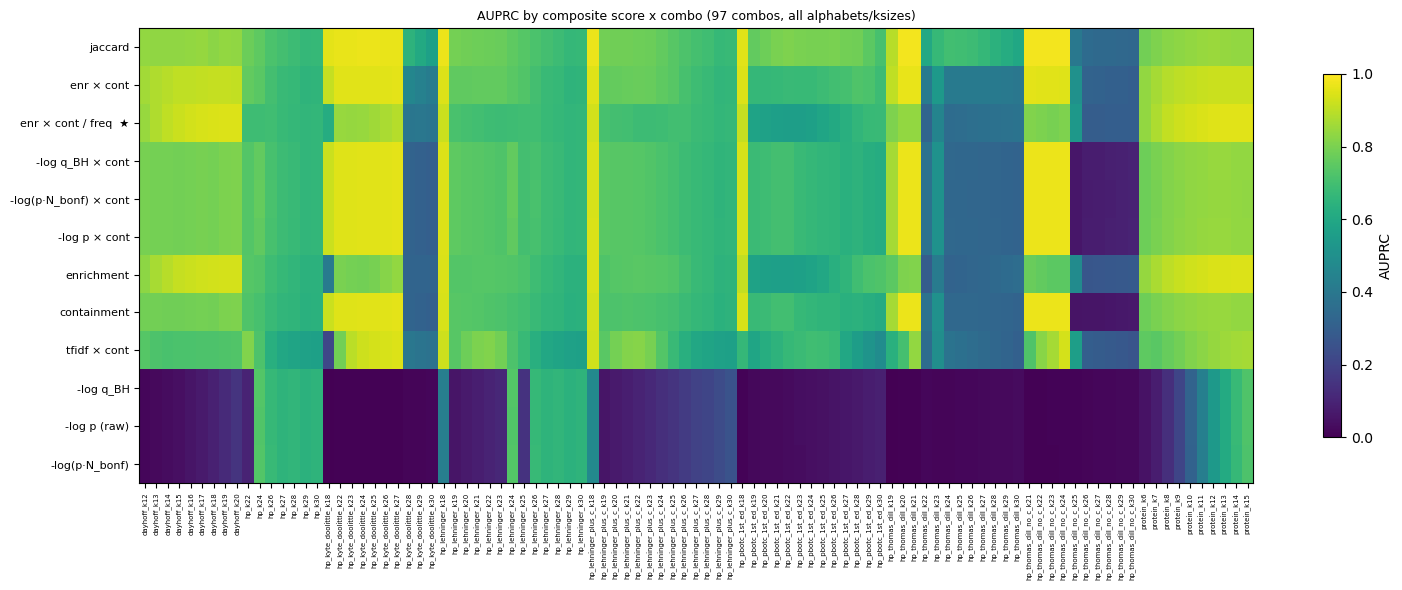

Metric win-counts across 97 combos:
shape: (6, 3)
┌─────────────────────────┬────────┬───────────────────────┐
│ metric                  ┆ n_wins ┆ label                 │
│ ---                     ┆ ---    ┆ ---                   │
│ str                     ┆ u32    ┆ str                   │
╞═════════════════════════╪════════╪═══════════════════════╡
│ jaccard                 ┆ 65     ┆ jaccard               │
│ score_enr_cont_freq     ┆ 17     ┆ enr × cont / freq  ★  │
│ score_tfidf_cont        ┆ 9      ┆ tfidf × cont          │
│ enrichment              ┆ 2      ┆ enrichment            │
│ score_bonf_neglogp_cont ┆ 2      ┆ -log(p·N_bonf) × cont │
│ score_enr_cont          ┆ 2      ┆ enr × cont            │
└─────────────────────────┴────────┴───────────────────────┘


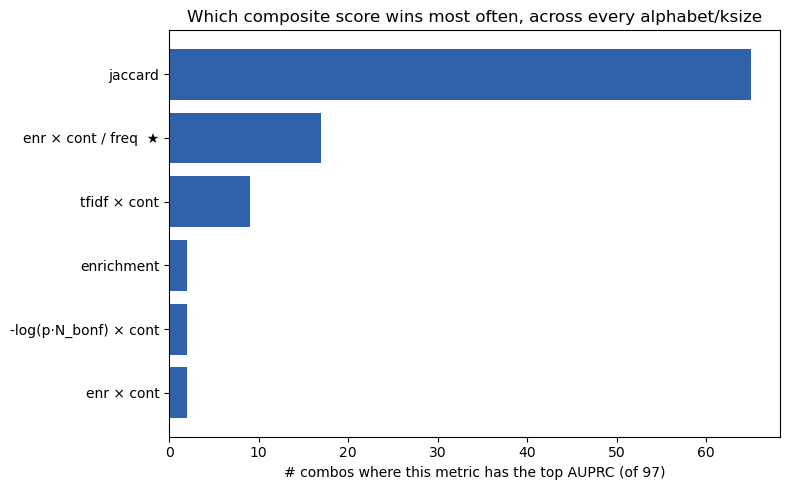

In [8]:
# Heatmap (metric x combo) rather than one bar-chart panel per combo -- ~100 combos x 12 metrics
# breaks a per-combo-panel layout the same way section 3's per-combo figures already did (see
# [[all_alphabets_ksizes_utility]]'s scale caveat).
leaderboard_all = leaderboard_all.with_columns(
    (pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("combo")
)
combo_order = (leaderboard_all.select(["encoding", "ksize", "combo"]).unique()
               .sort(["encoding", "ksize"])["combo"].to_list())
metric_order = (leaderboard_all.group_by("metric").agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
                .sort("mean_pr_auc", descending=True)["metric"].to_list())

# hp_lehninger_k18 / hp_lehninger_plus_c_k18 (the two combos that needed negative subsampling --
# see cell above) are flagged in red so the figure itself discloses which columns aren't
# full-data AUPRC.
subsampled_combos = set(
    leaderboard_all.filter(pl.col("subsampled"))
    .with_columns((pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("combo"))
    .select("combo").unique()["combo"].to_list()
)

pivot = (leaderboard_all.pivot(index="metric", on="combo", values="pr_auc")
         .to_pandas().set_index("metric").reindex(index=metric_order, columns=combo_order))

fig, ax = plt.subplots(figsize=(max(14, 0.16 * len(combo_order)), 6))
im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(metric_order)))
ax.set_yticklabels([ou.SCORE_LABELS.get(m, m) for m in metric_order], fontsize=8)
ax.set_xticks(range(len(combo_order)))
ax.set_xticklabels(combo_order, rotation=90, fontsize=5)
for tick, combo in zip(ax.get_xticklabels(), combo_order):
    if combo in subsampled_combos:
        tick.set_color("crimson")
        tick.set_fontweight("bold")
title = f"AUPRC by composite score x combo ({len(combo_order)} combos, all alphabets/ksizes)"
if subsampled_combos:
    title += (f"\n(red labels: negatives randomly subsampled to ~{NEGATIVE_SAMPLE_TARGET:,} -- "
              f"{', '.join(sorted(subsampled_combos))} -- all positives kept, see cell above)")
ax.set_title(title, fontsize=9)
fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_metric_leaderboard_all_combos_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Which metric wins each combo, and how often each metric wins overall -- generalizes the old
# "winning metric is alphabet-specific" finding from an n=2 anecdote to the full combo set.
best_per_combo = (leaderboard_all.sort("pr_auc", descending=True)
                   .group_by(["encoding", "ksize"], maintain_order=False).head(1))
win_counts = (best_per_combo.group_by("metric").agg(pl.len().alias("n_wins"))
              .sort("n_wins", descending=True))
print(f"Metric win-counts across {best_per_combo.height} combos:")
print(win_counts.with_columns(pl.col("metric").replace(ou.SCORE_LABELS).alias("label")))
if subsampled_combos:
    print(f"\n(negatives subsampled to ~{NEGATIVE_SAMPLE_TARGET:,} for: {', '.join(sorted(subsampled_combos))})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([ou.SCORE_LABELS.get(m, m) for m in win_counts["metric"].to_list()][::-1],
        win_counts["n_wins"].to_list()[::-1], color="#3062ac")
ax.set_xlabel(f"# combos where this metric has the top AUPRC (of {best_per_combo.height})")
ax.set_title("Which composite score wins most often, across every alphabet/ksize")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_metric_win_counts_all_combos.png", dpi=150, bbox_inches="tight")
plt.show()


**Updated 2026-08-05, full 97-combo sweep (was pending re-run; now complete).** The old n=2
comparison generalizes cleanly: **which composite metric wins is a property of the alphabet
family, not a per-combo coincidence.**

| winning metric | wins | almost entirely |
|---|---|---|
| `jaccard` | 65 / 97 | HP-family combos (65 of 78 HP combos) |
| `enr × cont / freq` (★ — this project's previously-favored composite) | 17 / 97 | protein (9/11) and dayhoff (8/9) |
| `tfidf × containment` | 9 / 97 | HP-family combos |
| everything else (`enrichment`, `enr × cont`, `-log(p·N_bonf) × cont` — 2 wins each) | 6 / 97 | scattered across all 3 families |

This confirms and generalizes the old hp_thomas_dill-k26 finding (jaccard wins, p-value-based
scores collapse to noise) as a genuine **HP-family property**: any 2-letter alphabet produces so
many coincidental k-mer matches that the Poisson null model stops discriminating true from false
pairs, so only jaccard's normalization-by-total-k-mer-count still carries signal. Protein and
dayhoff don't have this problem — their finer alphabets keep the Poisson p-value informative
enough that a p-value-weighted composite (`enr × cont / freq`) wins instead. **Practical
takeaway: pick the ranking metric by alphabet, not globally** — use `jaccard` for any HP variant,
`enr × cont / freq` for protein/dayhoff.


## 3. Full ranked comparison

29 alphabet × k-size combos, ranked by kmerseek's RBH F1. `gap_to_orthofinder` is OrthoFinder's
matched-scope F1 minus kmerseek's — smaller (closer to zero) is better for kmerseek; negative would
mean kmerseek actually exceeds OrthoFinder on that combo.

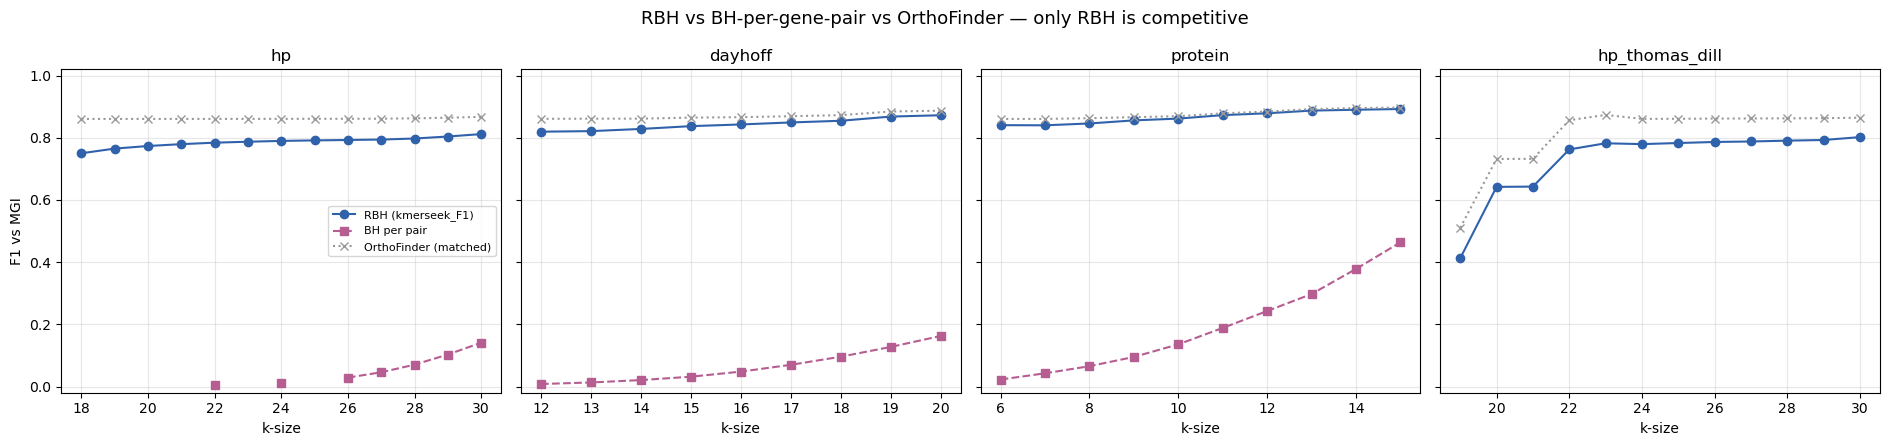

In [9]:
# Three calling methods, side by side, per alphabet (+hp_thomas_dill) -- confirms RBH is the only one competitive
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), sharey=True)
for ax, enc in zip(axes, ["hp", "dayhoff", "protein", "hp_thomas_dill"]):
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(sub["ksize"], sub["kmerseek_F1"], "o-", color="#3062ac", label="RBH (kmerseek_F1)")
    ax.plot(sub["ksize"], sub["bh_per_pair_F1"], "s--", color="#b65d91", label="BH per pair")
    ax.plot(sub["ksize"], sub["orthofinder_F1_matched"], "x:", color="#999999", label="OrthoFinder (matched)")
    ax.set_title(enc, fontsize=12)
    ax.set_xlabel("k-size")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.02)
    if ax is axes[0]:
        ax.set_ylabel("F1 vs MGI")
        ax.legend(fontsize=8)
fig.suptitle("RBH vs BH-per-gene-pair vs OrthoFinder — only RBH is competitive", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_three_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

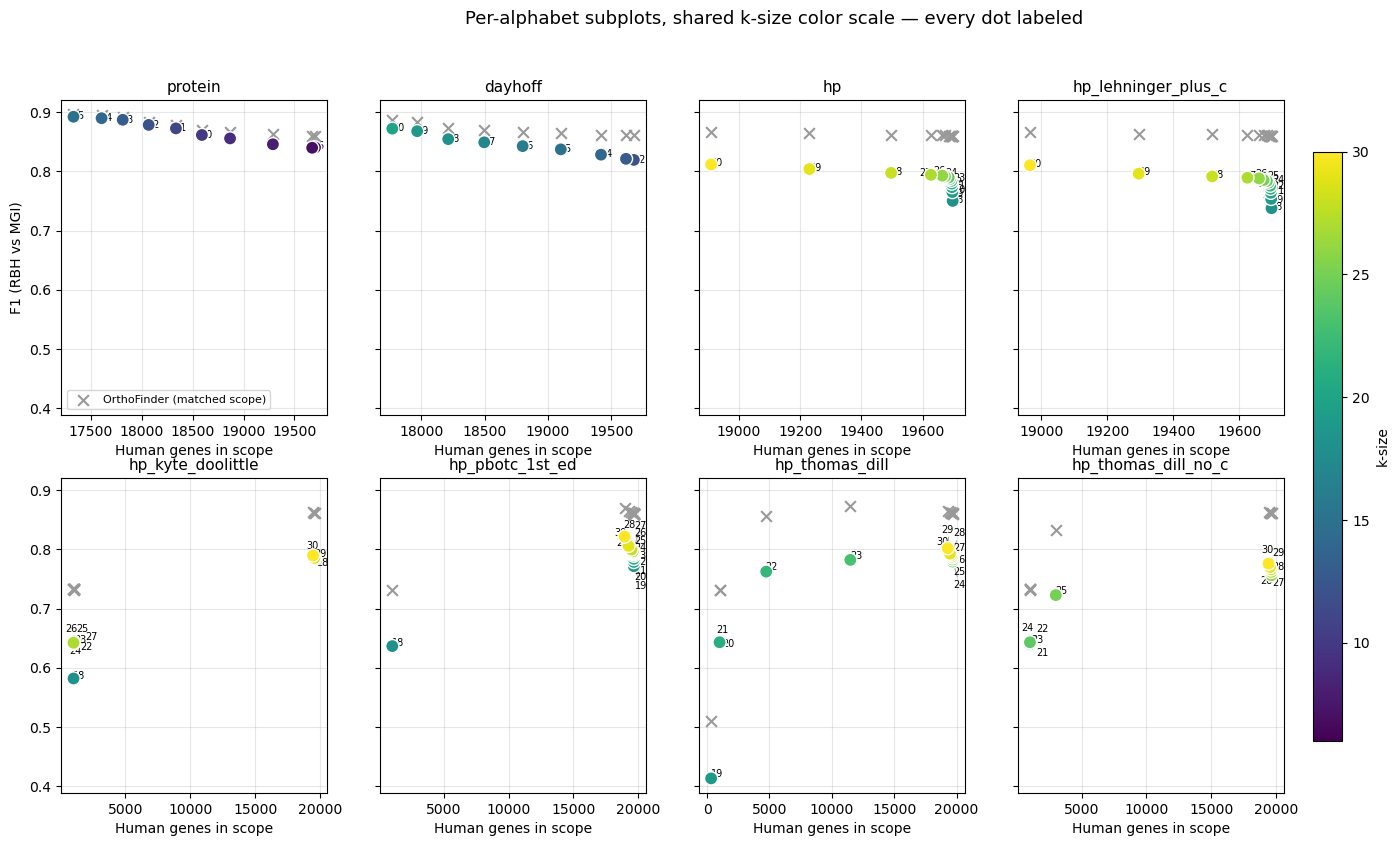

In [10]:
# Per-alphabet subplots, shared k-size color scale, every dot labeled with its k-size
# (adjustText repels overlapping labels apart, drawing a thin leader line back to its dot).
# 8 panels: protein, dayhoff, plain hp, and the 5 genuinely-distinct HP variants -- hp_lehninger
# itself is dropped here (byte-identical to plain "hp", see the imports cell) to avoid plotting
# the same alphabet twice; it stays in sweep_df_ext / the table above for reference.
from adjustText import adjust_text

ENCODINGS = ["protein", "dayhoff", "hp", "hp_lehninger_plus_c", "hp_kyte_doolittle",
             "hp_pbotc_1st_ed", "hp_thomas_dill", "hp_thomas_dill_no_c"]
K_MIN, K_MAX = sweep_df_ext["ksize"].min(), sweep_df_ext["ksize"].max()

fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    ax.scatter(sub["n_genes_scope"], sub["orthofinder_F1_matched"],
               marker="x", s=60, color="#999999", zorder=4, label="OrthoFinder (matched scope)")
    sc = ax.scatter(sub["n_genes_scope"], sub["kmerseek_F1"], c=sub["ksize"],
                     cmap="viridis", vmin=K_MIN, vmax=K_MAX, s=90, zorder=5, edgecolor="white")
    texts = [ax.text(x, y, f"{k}", fontsize=7)
             for x, y, k in zip(sub["n_genes_scope"], sub["kmerseek_F1"], sub["ksize"])]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.5))
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("Human genes in scope")
    ax.grid(True, alpha=0.3)
    if ax is axes.flat[0]:
        ax.set_ylabel("F1 (RBH vs MGI)")
        ax.legend(fontsize=8, loc="lower left")

fig.colorbar(sc, ax=axes, label="k-size", shrink=0.85, pad=0.02)
fig.suptitle("Per-alphabet subplots, shared k-size color scale — every dot labeled", fontsize=13)
plt.savefig(DATA_DIR / "200_sweep_variant1_subplots_shared_scale.png", dpi=150, bbox_inches="tight")
plt.show()

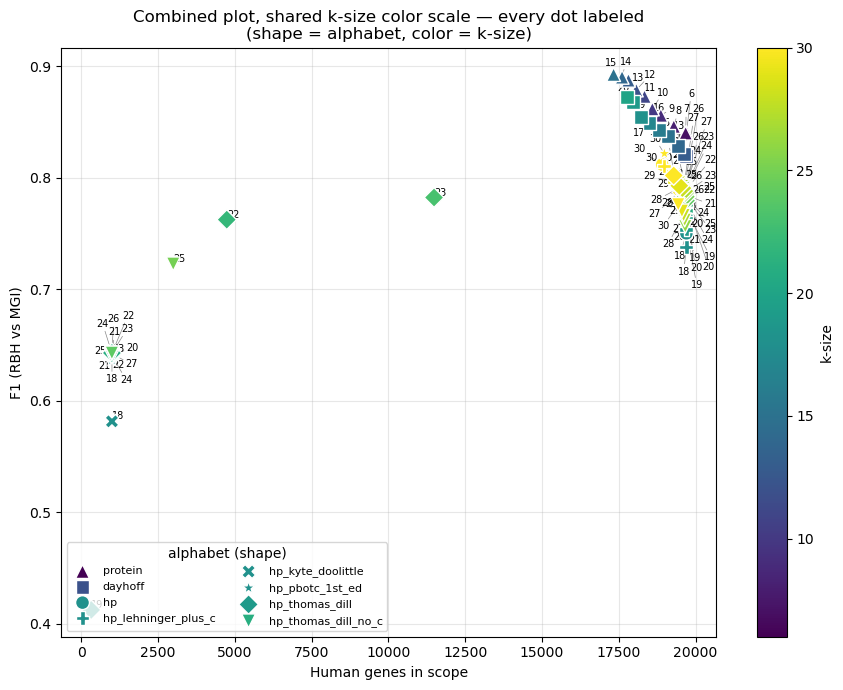

In [11]:
# All alphabets combined on ONE plot, shared k-size color scale, every dot labeled
# (adjustText repels overlapping labels apart, drawing a thin leader line back to its dot)
MARKERS = {"protein": "^", "dayhoff": "s", "hp": "o", "hp_lehninger_plus_c": "P",
           "hp_kyte_doolittle": "X", "hp_pbotc_1st_ed": "*", "hp_thomas_dill": "D",
           "hp_thomas_dill_no_c": "v"}

fig, ax = plt.subplots(figsize=(9, 7))
all_texts = []
for enc in ENCODINGS:
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    sc = ax.scatter(sub["n_genes_scope"], sub["kmerseek_F1"], c=sub["ksize"],
                     cmap="viridis", vmin=K_MIN, vmax=K_MAX, marker=MARKERS[enc],
                     s=100, zorder=5, edgecolor="white", label=enc)
    all_texts += [ax.text(x, y, f"{k}", fontsize=7)
                  for x, y, k in zip(sub["n_genes_scope"], sub["kmerseek_F1"], sub["ksize"])]
adjust_text(all_texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.5))

ax.set_xlabel("Human genes in scope")
ax.set_ylabel("F1 (RBH vs MGI)")
ax.set_title("Combined plot, shared k-size color scale — every dot labeled\n(shape = alphabet, color = k-size)")
ax.grid(True, alpha=0.3)
ax.legend(title="alphabet (shape)", fontsize=8, loc="lower left", ncol=2)
fig.colorbar(sc, ax=ax, label="k-size")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_sweep_variant3_combined_shared_scale.png", dpi=150, bbox_inches="tight")
plt.show()

## 3b. k-size vs continuous ranking quality (AUC), all alphabets

`kmerseek_F1` above scores RBH's single best hit per gene. A separate question (section 2b):
if you rank *every* candidate gene pair by raw containment instead of taking only each gene's
best hit, how well does that ranking separate true MGI orthologs from everything else? That's
`roc_auc`/`pr_auc` from `rbh_vs_matched_orthofinder` — same underlying data, no extra I/O.

Raw AUC alone doesn't penalize a combo for covering fewer genes (`n_genes_scope` ranges
~17.3k-19.7k across combos — see the per-alphabet subplots above). `auc_x_n` and `auc_x_logn`
weight AUC by coverage, so an alphabet/k-size that ranks well but only covers a narrow slice of
genes doesn't look artificially strong next to one that ranks well across nearly the whole
genome.

**k-size itself isn't a fair x-axis across alphabets.** HP's 2-letter alphabet and protein's
20-letter alphabet don't carry the same information per position, so "HP k=30 vs protein k=15"
compares a 30-bit-ish window against a ~63-bit-ish window under the same x-value — not remotely
matched. `bits_per_kmer` (`ou.bits_per_kmer`, saved to [[alphabet_bits_utility]] so every other
notebook can reuse it) fixes this properly: instead of the naive `ksize * log2(n_symbols)` —
which assumes every encoded symbol is equally likely — it computes real Shannon entropy per
symbol from the actual amino-acid usage frequency in the human+mouse proteomes this project
searches, grouped exactly the way kmerseek's own encoding tables group them. The plots below
repeat the k-size-vs-AUC comparison on this bits axis instead, which is what actually makes
protein/dayhoff/HP comparable.



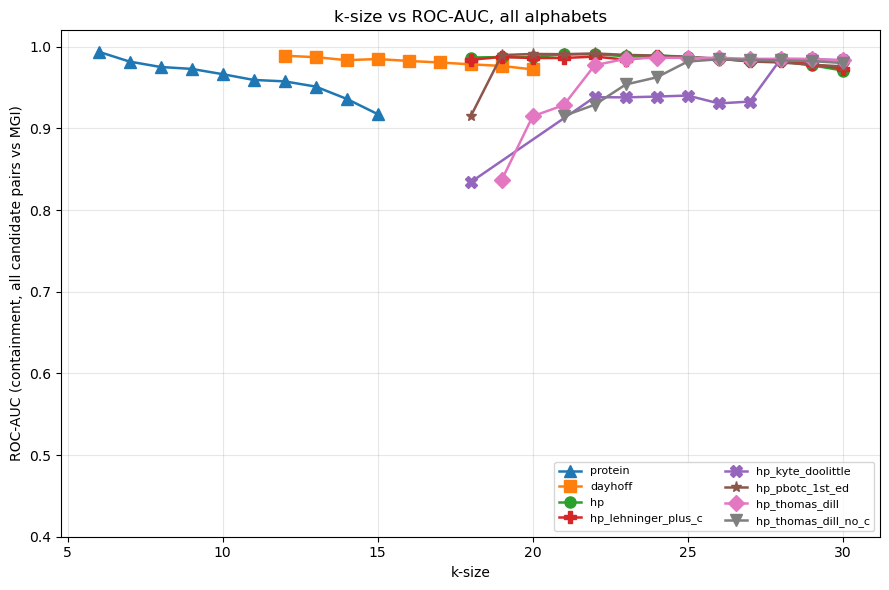

In [12]:
# k-size vs ROC-AUC, all alphabets on one plot (same ENCODINGS/MARKERS as the combined plot above)
fig, ax = plt.subplots(figsize=(9, 6))
for enc in ENCODINGS:
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    if sub.height == 0:
        continue
    ax.plot(sub["ksize"], sub["roc_auc"], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
ax.set_xlabel("k-size")
ax.set_ylabel("ROC-AUC (jaccard, all candidate pairs vs MGI)")
ax.set_title("k-size vs ROC-AUC, all alphabets")
ax.set_ylim(0.4, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_ksize_vs_auc_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

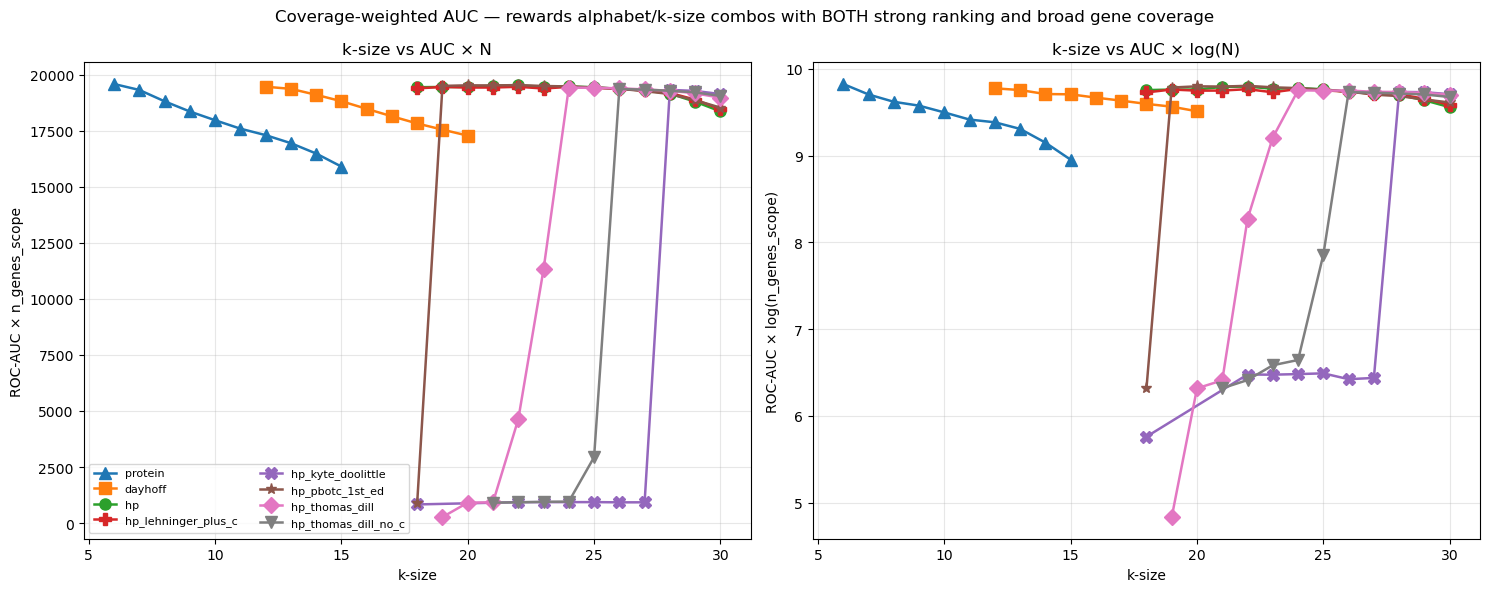

Best by kmerseek_F1   : protein              k=15  (kmerseek_F1=0.8925, n_genes_scope=17,328)
Best by roc_auc       : protein              k= 6  (roc_auc=0.9938, n_genes_scope=19,702)
Best by auc_x_n       : protein              k= 6  (auc_x_n=19579.5056, n_genes_scope=19,702)
Best by auc_x_logn    : protein              k= 6  (auc_x_logn=9.8270, n_genes_scope=19,702)

Best k-size PER ALPHABET, ranked by roc_auc:
shape: (9, 5)
┌─────────────────────┬───────┬──────────┬─────────────┬───────────────┐
│ encoding            ┆ ksize ┆ roc_auc  ┆ kmerseek_F1 ┆ n_genes_scope │
│ ---                 ┆ ---   ┆ ---      ┆ ---         ┆ ---           │
│ str                 ┆ i64   ┆ f64      ┆ f64         ┆ i64           │
╞═════════════════════╪═══════╪══════════╪═════════════╪═══════════════╡
│ protein             ┆ 6     ┆ 0.993783 ┆ 0.84052     ┆ 19702         │
│ hp_pbotc_1st_ed     ┆ 22    ┆ 0.991696 ┆ 0.789287    ┆ 19694         │
│ hp_lehninger        ┆ 22    ┆ 0.990793 ┆ 0.784342    ┆ 1

In [13]:
# k-size vs coverage-weighted AUC (AUC x N, AUC x logN), all alphabets
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, ycol, ylabel, title in [
    (axes[0], "auc_x_n",    "ROC-AUC × n_genes_scope",       "k-size vs AUC × N"),
    (axes[1], "auc_x_logn", "ROC-AUC × log(n_genes_scope)",  "k-size vs AUC × log(N)"),
]:
    for enc in ENCODINGS:
        sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
        if sub.height == 0:
            continue
        ax.plot(sub["ksize"], sub[ycol], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
    ax.set_xlabel("k-size")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, ncol=2, loc="best")
fig.suptitle("Coverage-weighted AUC — rewards alphabet/k-size combos with BOTH strong ranking "
             "and broad gene coverage", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_ksize_vs_auc_weighted_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

# Which alphabet/k-size wins by each metric? (top row per metric)
for col in ["kmerseek_F1", "roc_auc", "auc_x_n", "auc_x_logn"]:
    top = sweep_df_ext.sort(col, descending=True).head(1)
    r = top.row(0, named=True)
    print(f"Best by {col:14s}: {r['encoding']:20s} k={r['ksize']:>2}  "
          f"({col}={r[col]:.4f}, n_genes_scope={r['n_genes_scope']:,})")

print("\nBest k-size PER ALPHABET, ranked by roc_auc:")
best_per_alphabet_auc = (
    sweep_df_ext.sort("roc_auc", descending=True)
    .group_by("encoding", maintain_order=False)
    .head(1)
    .sort("roc_auc", descending=True)
)
print(best_per_alphabet_auc.select(["encoding", "ksize", "roc_auc", "kmerseek_F1", "n_genes_scope"]))

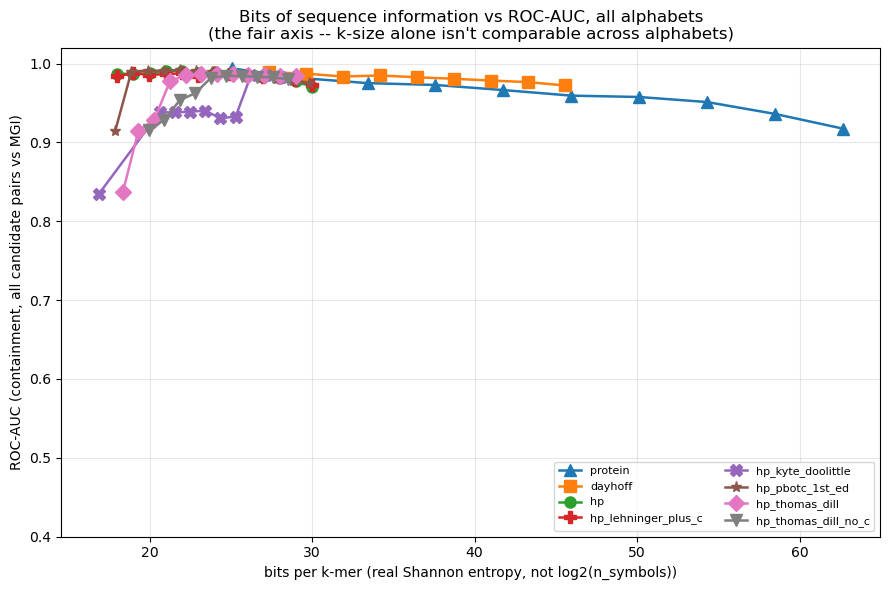

At matched bits_per_kmer (25-31, HP's native range) -- ROC-AUC by combo:
shape: (39, 5)
┌─────────────────────┬───────┬───────────────┬──────────┬─────────────┐
│ encoding            ┆ ksize ┆ bits_per_kmer ┆ roc_auc  ┆ kmerseek_F1 │
│ ---                 ┆ ---   ┆ ---           ┆ ---      ┆ ---         │
│ str                 ┆ i64   ┆ f64           ┆ f64      ┆ f64         │
╞═════════════════════╪═══════╪═══════════════╪══════════╪═════════════╡
│ protein             ┆ 6     ┆ 25.058028     ┆ 0.993783 ┆ 0.84052     │
│ dayhoff             ┆ 12    ┆ 27.336011     ┆ 0.988864 ┆ 0.819466    │
│ hp_lehninger        ┆ 25    ┆ 25.000785     ┆ 0.987786 ┆ 0.79145     │
│ hp                  ┆ 25    ┆ 25.000785     ┆ 0.987786 ┆ 0.79145     │
│ dayhoff             ┆ 13    ┆ 29.614012     ┆ 0.987152 ┆ 0.821277    │
│ …                   ┆ …     ┆ …             ┆ …        ┆ …           │
│ hp_pbotc_1st_ed     ┆ 30    ┆ 29.81296      ┆ 0.975896 ┆ 0.821607    │
│ hp_lehninger_plus_c ┆ 30    ┆ 29.9

In [14]:
# Bits vs ROC-AUC -- the fair cross-alphabet comparison (see [[alphabet_bits_utility]] /
# section 3b markdown). Same ENCODINGS/MARKERS as the k-size plots above, just a different
# x-axis: real Shannon-entropy bits per k-mer instead of raw k, computed from the actual
# human+mouse amino-acid usage frequency grouped the way each alphabet's kmerseek encoding
# table groups it -- NOT ksize * log2(n_symbols).
fig, ax = plt.subplots(figsize=(9, 6))
for enc in ENCODINGS:
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("bits_per_kmer")
    if sub.height == 0:
        continue
    ax.plot(sub["bits_per_kmer"], sub["roc_auc"], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
ax.set_xlabel("bits per k-mer (real Shannon entropy, not log2(n_symbols))")
ax.set_ylabel("ROC-AUC (jaccard, all candidate pairs vs MGI)")
ax.set_title("Bits of sequence information vs ROC-AUC, all alphabets\n(the fair axis -- k-size alone isn't comparable across alphabets)")
ax.set_ylim(0.4, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_bits_vs_auc_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

# At matched information content, is HP actually competitive with protein/dayhoff, or does
# "needs a longer k because it's a coarser alphabet" only account for PART of the gap?
BITS_LO, BITS_HI = 25, 31  # HP's native bits_per_kmer range (k=18-30) sits almost entirely here
matched = (sweep_df_ext.filter(pl.col("bits_per_kmer").is_between(BITS_LO, BITS_HI))
           .sort("roc_auc", descending=True))
print(f"At matched bits_per_kmer ({BITS_LO}-{BITS_HI}, HP's native range) -- ROC-AUC by combo:")
print(matched.select(["encoding", "ksize", "bits_per_kmer", "roc_auc", "kmerseek_F1"]))

best_hp_matched = matched.filter(pl.col("encoding").str.starts_with("hp")).head(1)
best_non_hp_matched = matched.filter(~pl.col("encoding").str.starts_with("hp")).head(1)
if best_hp_matched.height and best_non_hp_matched.height:
    hp_r, non_hp_r = best_hp_matched.row(0, named=True), best_non_hp_matched.row(0, named=True)
    print(f"\nAt matched information content: best non-HP ({non_hp_r['encoding']} k={non_hp_r['ksize']}, "
          f"{non_hp_r['bits_per_kmer']:.1f} bits) roc_auc={non_hp_r['roc_auc']:.4f} vs "
          f"best HP ({hp_r['encoding']} k={hp_r['ksize']}, {hp_r['bits_per_kmer']:.1f} bits) "
          f"roc_auc={hp_r['roc_auc']:.4f} -- gap={non_hp_r['roc_auc']-hp_r['roc_auc']:.4f}")


## 4. Top-5-per-alphabet combos → carried into notebook 201's MHC deep-dive

Rather than a strict global top-5 (which would be all-protein-plus-one-dayhoff and skip HP entirely),
this takes the **top 5 combos within each alphabet** — 5 protein + 5 dayhoff + 5 HP = 15 combos total.
This matters because HP never cracks the global top 5 genome-wide, but an earlier MHC-specific run (a
different HP variant, thomas_dill) scored far better on MHC class I than any protein/dayhoff combo —
so excluding HP from the MHC follow-up would risk missing exactly the alphabet family most likely to
matter for that hard case.

In [15]:
TOP5_CSV = DATA_DIR / "200_top5_alphabet_ksize_combos.csv"
top5_per_alphabet = (
    sweep_df.sort("kmerseek_F1", descending=True)
    .group_by("encoding", maintain_order=False)
    .head(5)
    .sort(["encoding", "kmerseek_F1"], descending=[False, True])
)
top5_per_alphabet.write_csv(TOP5_CSV)
print(f"Saved {top5_per_alphabet.height} combos (top-5-per-alphabet) to {TOP5_CSV.name}")
top5_per_alphabet.select(["encoding", "ksize", "kmerseek_F1", "orthofinder_F1_matched", "gap_to_orthofinder"])

Saved 15 combos (top-5-per-alphabet) to 200_top5_alphabet_ksize_combos.csv


encoding,ksize,kmerseek_F1,orthofinder_F1_matched,gap_to_orthofinder
str,i64,f64,f64,f64
"""dayhoff""",20,0.872354,0.886977,0.014623
"""dayhoff""",19,0.86806,0.884333,0.016273
"""dayhoff""",18,0.854588,0.872645,0.018056
"""dayhoff""",17,0.849188,0.869227,0.020039
"""dayhoff""",16,0.842763,0.866125,0.023363
…,…,…,…,…
"""protein""",15,0.892473,0.897054,0.004581
"""protein""",14,0.890003,0.89539,0.005387
"""protein""",13,0.887342,0.892116,0.004774


## 5. Beyond raw F1: what kmerseek finds that OrthoFinder misses

kmerseek doesn't need to beat OrthoFinder on aggregate F1 to be useful — the more interesting question
is what it recovers that a 1:1 orthogroup-clustering tool structurally can't. A prior analysis
(notebook 120, HP Lehninger k=24, conservative Bonferroni threshold) already identified 1,114 unique
gene pairs where **kmerseek and MGI agree** a pair is a true ortholog but **OrthoFinder missed it**.
The natural follow-up: are these genuine 1:1 relationships OrthoFinder simply overlooked, or are they
concentrated in large, rapidly-duplicated gene families — the exact scenario where a tool built around
1:1 orthogroup clustering is expected to struggle?

Checked against two independent real databases (not name-pattern matching): **MGI's own homology-class
size** (how many human/mouse genes share that gene's MGI `DB Class Key`) and **HGNC's curated
gene-family membership** (`gene_group_id`, spot-checked for known families rather than used as the
primary metric — some HGNC groups are generic multi-hundred-member buckets, not true evolutionary
families).

kmerseek-only pairs (MGI-true, OrthoFinder-missed): 1,114 unique gene pairs

In an MGI multi-gene homology class (class size > 1): 744 / 1,114 (66.8%)
Clean single-copy 1:1 MGI class (size == 1):          369 / 1,114 (33.1%)

Examples with MGI class size >= 10 (rapidly-duplicated families):
  PRAMEF10     vs PRAMEL32      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF12     vs PRAMEL19      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF17     vs PRAMEL32      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF20     vs PRAMEL32      MGI_class_size= 21  HGNC_family=PRAME family
  FAM90A5      vs FAM90A1B      MGI_class_size= 21  HGNC_family=None
  PRAMEF33     vs PRAMEL32      MGI_class_size= 21  HGNC_family=None
  PRAMEF19     vs PRAMEL31      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF14     vs PRAMEL5       MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF2      vs PRAMEL61      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF14     vs PRAMEL61     

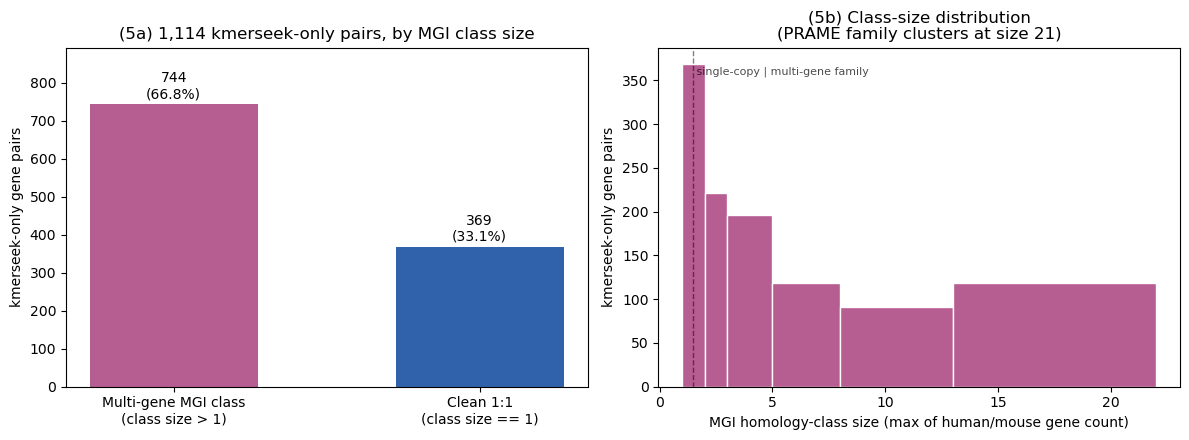

In [16]:
KO_ONLY_CSV = DATA_DIR / "120_kmerseek_only_pairs.csv"
HGNC_TXT = DATA_DIR / "hgnc_complete_set.txt"

# MGI homology-class size: how many human / mouse genes share the same DB Class Key
h_all = mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606).select(["DB Class Key", "Symbol"]).rename({"Symbol": "human_gene"}).with_columns(pl.col("human_gene").str.to_uppercase())
m_all = mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090).select(["DB Class Key", "Symbol"]).rename({"Symbol": "mouse_gene"}).with_columns(pl.col("mouse_gene").str.to_uppercase())
class_n_human = h_all.group_by("DB Class Key").agg(pl.col("human_gene").n_unique().alias("n_human_in_class"))
class_n_mouse = m_all.group_by("DB Class Key").agg(pl.col("mouse_gene").n_unique().alias("n_mouse_in_class"))
mouse_to_class: dict[str, set] = {}
for row in m_all.iter_rows(named=True):
    mouse_to_class.setdefault(row["mouse_gene"], set()).add(row["DB Class Key"])
class_size = {
    row["DB Class Key"]: (row["n_human_in_class"] or 0, row["n_mouse_in_class"] or 0)
    for row in class_n_human.join(class_n_mouse, on="DB Class Key", how="full", coalesce=True).iter_rows(named=True)
}

kmerseek_only = (
    pl.read_csv(KO_ONLY_CSV).select(["human_gene_name", "mouse_gene_name"]).unique()
    .with_columns([pl.col("human_gene_name").str.to_uppercase().alias("human_gene"),
                   pl.col("mouse_gene_name").str.to_uppercase().alias("mouse_gene")])
)
print(f"kmerseek-only pairs (MGI-true, OrthoFinder-missed): {kmerseek_only.height:,} unique gene pairs")

family_rows = []
for r in kmerseek_only.iter_rows(named=True):
    classes = mouse_to_class.get(r["mouse_gene"], set())
    n_h = max((class_size.get(c, (0, 0))[0] for c in classes), default=0)
    n_m = max((class_size.get(c, (0, 0))[1] for c in classes), default=0)
    family_rows.append(dict(human_gene=r["human_gene"], mouse_gene=r["mouse_gene"],
                             mgi_class_size=max(n_h, n_m)))
family_df = pl.DataFrame(family_rows)

n_expanded = int((family_df["mgi_class_size"] > 1).sum())
n_single = int((family_df["mgi_class_size"] == 1).sum())
n_total = family_df.height
print(f"\nIn an MGI multi-gene homology class (class size > 1): {n_expanded:,} / {n_total:,} ({n_expanded/n_total:.1%})")
print(f"Clean single-copy 1:1 MGI class (size == 1):          {n_single:,} / {n_total:,} ({n_single/n_total:.1%})")

hgnc = pl.read_csv(HGNC_TXT, separator="\t", infer_schema_length=50_000, null_values=[""])
sym2fam = dict(zip(
    hgnc.select("symbol").with_columns(pl.col("symbol").str.to_uppercase())["symbol"].to_list(),
    hgnc["gene_group"].to_list(),
))
big = family_df.filter(pl.col("mgi_class_size") >= 10).sort("mgi_class_size", descending=True)
print("\nExamples with MGI class size >= 10 (rapidly-duplicated families):")
for row in big.head(10).iter_rows(named=True):
    fam = sym2fam.get(row["human_gene"], "?")
    print(f"  {row['human_gene']:12s} vs {row['mouse_gene']:12s}  MGI_class_size={row['mgi_class_size']:3d}  HGNC_family={fam}")

# --- Figure: same finding, visualized ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.bar(["Multi-gene MGI class\n(class size > 1)", "Clean 1:1\n(class size == 1)"],
        [n_expanded, n_single], color=["#b65d91", "#3062ac"], width=0.55)
for i, v in enumerate([n_expanded, n_single]):
    axL.text(i, v + 15, f"{v:,}\n({v/n_total:.1%})", ha="center", fontsize=10)
axL.set_ylabel("kmerseek-only gene pairs")
axL.set_title(f"(5a) {n_total:,} kmerseek-only pairs, by MGI class size")
axL.set_ylim(0, max(n_expanded, n_single) * 1.2)

bins = [1, 2, 3, 5, 8, 13, 22]  # roughly matches the observed class-size distribution
axR.hist(family_df["mgi_class_size"].to_numpy(), bins=bins, color="#b65d91", edgecolor="white", align="mid")
axR.axvline(1.5, color="black", ls="--", alpha=0.5, lw=1)
axR.text(1.5, axR.get_ylim()[1] * 0.92, " single-copy | multi-gene family", fontsize=8, alpha=0.7)
axR.set_xlabel("MGI homology-class size (max of human/mouse gene count)")
axR.set_ylabel("kmerseek-only gene pairs")
axR.set_title("(5b) Class-size distribution\n(PRAME family clusters at size 21)")

plt.tight_layout()
plt.savefig(DATA_DIR / "200_kmerseek_only_family_size.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Verdict

**Updated 2026-08-05.** Section 3b's `roc_auc`/`auc_x_n`/`auc_x_logn` and `bits_per_kmer` are now
fully populated (`200_alphabet_ksize_matched_scope_comparison.csv` and
`200_hp_variants_full_sweep.csv` both re-ran clean) and section 2b's 97-combo metric-leaderboard
sweep also completed — every AUC/bits claim below is current, not pending.

**Alphabet/k-size ranking (by F1).** Full 20-amino-acid **protein** encoding at **k=15** comes
closest to OrthoFinder (F1=0.892, gap≈0.005), with **dayhoff k=20** the strongest reduced alphabet
(F1=0.872, gap≈0.015). Every HP-family alphabet trails both by a wider margin (gap ≥ 0.048 at
best).

**AUC tells a different story than F1, and the difference is informative, not noise.** F1's
overall winner (protein k=15) is NOT the AUC winner: ranked by `roc_auc` (label every candidate
pair, not just each gene's single RBH-selected best hit), **protein k=6** wins outright
(roc_auc=0.994) — a much shorter k than F1 prefers. That's because RBH-F1 rewards a threshold
call being *precise* (each gene picks exactly one best hit), while AUC rewards the *entire
ranking* being well-ordered, which a shorter, less specific k-mer can do well at even though it's
too promiscuous to trust as a single best-hit call. These are different questions — "what's the
best single call" vs. "how good is the whole ranked list" — and this sweep is what actually shows
they don't agree here.

**Bits, not k-size, is the fair axis for comparing alphabets — and HP still trails on it.**
Because HP's 2-letter alphabet and protein's 20-letter alphabet don't carry the same information
per position, "HP k=30 vs protein k=15" was never actually a fair comparison (~30 bits vs ~63
bits of real sequence information — see `ou.bits_per_kmer`, [[alphabet_bits_utility]]). Re-running
the comparison at *matched* bits (25-31, HP's native k=18-30 range) still shows protein ahead:
protein k=6 (25.1 bits) reaches roc_auc=0.994 vs the best HP variant at essentially the same bit
budget, `hp_lehninger` k=25 (25.0 bits) at roc_auc=0.988 — protein by +0.006 AUC. **The gap is
real but modest once alphabet coarseness is actually accounted for** — most of HP's raw
F1/AUC deficit against protein *is* explained by needing a coarser alphabet, not by HP being a
categorically worse signal; what's left over (~0.006 AUC at matched information) is a small,
genuine residual gap, not the dramatic-looking gap a naive k-size-only comparison implies.

**Which HP alphabet actually performs best: `hp_pbotc_1st_ed`, not `hp_thomas_dill`.** Now that the
full 6-variant sweep has actually run (rather than the earlier hp_thomas_dill-only k25/26 patch),
the best-F1-per-alphabet ranking among HP variants, all at their best k=30, is:

| encoding | best F1 (k=30) | gap to OrthoFinder |
|---|---|---|
| hp_pbotc_1st_ed | **0.8216** | 0.0477 |
| hp_lehninger (= plain hp) | 0.8121 | 0.0551 |
| hp_lehninger_plus_c | 0.8104 | 0.0557 |
| hp_thomas_dill | 0.8020 | 0.0625 |
| hp_kyte_doolittle | 0.7898 | 0.0742 |
| hp_thomas_dill_no_c | 0.7759 | 0.0865 |

`hp_pbotc_1st_ed` beats plain HP Lehninger by ~0.010 F1 and beats `hp_thomas_dill` by ~0.020 F1 —
a real, if modest, genome-wide edge, not noise (consistent across k=22-30, not just k=30; see the
per-alphabet subplots and combined plot above). `hp_pbotc_1st_ed` is also the best HP variant by
raw AUC (0.992 at k=22, before any bits-matching), so this isn't an F1-only artifact.
**`hp_thomas_dill` is NOT the best HP variant genome-wide** — it lands 4th of 6, ahead of only
kyte_doolittle and its own no-c variant. Its documented advantage (notebook 201) is specific to
the MHC class I stress test, not a genome-wide property — this sweep is what actually surfaces
that distinction, since a genome-wide average would hide it either way.

**Which ranking metric to use also depends on alphabet family (section 2b, full 97-combo sweep).**
`jaccard` wins outright for 65/78 HP-family combos; a p-value-weighted composite
(`enr × containment / mean_matched_kmer_freq`) wins for 17/20 protein+dayhoff combos instead —
because HP's coarse alphabet produces so many coincidental k-mer matches that the Poisson null
model stops discriminating true from false pairs, leaving only jaccard's normalization with real
signal. See section 2b's verdict cell for the full breakdown.

**On "beating" OrthoFinder.** It doesn't, once OrthoFinder is scored fairly (matched gene universe)
— but it gets close, and closeness alone isn't the interesting part of the story.

**What kmerseek adds beyond the F1 number.** Of the 1,114 gene pairs where kmerseek recovers an
MGI-documented true ortholog that OrthoFinder's 1:1 orthogroup clustering missed, roughly two-thirds
sit inside a multi-gene MGI homology class (families like PRAME, several zinc-finger subfamilies, and
MHC class I/H-2) — exactly the regime where a method built around single-best-hit clustering is
expected to struggle, and where kmerseek's containment-based search still lands a hit. That's a
concrete, distinct capability rather than an aggregate-metric contest.
